# Confidence Intervals

### General Instructions
- You must submit a single file that includes:
  - Clearly commented R code
  - Numerical results
  - Short written interpretations where explicitly requested
- Do **not** use built-in functions that directly return confidence intervals (e.g., `t.test(..., conf.level=...)`) unless explicitly allowed.
- Set a random seed at the beginning of your analysis using your **student ID**.

## Part 1 — Sampling and Point Estimation

In this assignment, we study confidence intervals for the population mean using real data.

### Data
Use the Ames housing dataset. Load the data using:

```r
ames <- read.csv("http://www.jkarreth.net/files/ames.csv")
population <- ames$Gr.Liv.Area
```

### Exercise 1
1. Set a random seed equal to your student ID.
2. Take a **simple random sample of size 60** from `population`.
3. Compute the sample mean and sample standard deviation.
4. Plot a histogram of the sampled data and briefly describe its shape.

## Part 2 — Confidence Interval for the Mean

Recall that a $100(1-\alpha)\%$ confidence interval for the population mean is given by
$$
\bar{X} \pm z_{\alpha/2} \frac{S}{\sqrt{n}}.
$$

### Exercise 2
1. Using your sample from Part 1, compute a **95% confidence interval** for the population mean **manually** (do not use `t.test`).
2. Clearly show how you compute the standard error and the critical value.
3. Interpret the confidence interval **in context** of house sizes.

## Part 3 — Effect of Confidence Level


### Exercise 3
1. Compute confidence intervals for the population mean using the same sample for the following confidence levels:
   - 90%
   - 95%
   - 99%
2. Report all intervals.
3. Compare the widths of these intervals. What do you observe as the confidence level increases?

## Part 4 — Repeated Sampling and Coverage Probability


In this part, we investigate the long-run behavior of confidence intervals.


### Exercise 4
1. Set the sample size to $n = 75$.
2. Using a `for` loop, repeat the following procedure **50 times**:
   - Take a random sample of size $n$ from the population
   - Compute the sample mean and sample standard deviation
   - Construct a 95% confidence interval
3. Store the lower and upper bounds of all confidence intervals.

## Part 5 — Empirical Confidence Level


### Exercise 5
1. Compute the true population mean using the full dataset.
2. Determine how many of the 50 confidence intervals contain the true population mean.
3. Compute the proportion of intervals that contain the true mean.
4. Is this proportion exactly equal to 95%? Explain why or why not.

## Part 6 — Visualization


### Exercise 6
1. Plot all 50 confidence intervals on a single figure.
2. Clearly indicate which intervals contain the true population mean and which do not.
3. Include a vertical or horizontal reference line for the true mean.

## Part 7 — Effect of Sample Size


### Exercise 7
Repeat **Part 4 and Part 5** for the following sample sizes:
- $n = 30$
- $n = 120$

Compare the resulting interval widths and empirical coverage probabilities. Summarize your findings.

## Submission Checklist

- [ ] R code runs without errors
- [ ] All plots are labeled and readable
- [ ] All interpretations are written clearly and concisely
- [ ] Random seed is set correctly

### Learning Objectives
By completing this assignment, you should be able to:
- Construct confidence intervals for a population mean in R
- Understand the role of confidence level and sample size
- Empirically verify the meaning of a confidence level
- Use simulation to study statistical inference

[1] 1412.652 1687.614

$`90%`
[1] 1435.319 1664.948

$`95%`
[1] 1412.652 1687.614

$`99%`
[1] 1367.254 1733.013

[1] 1

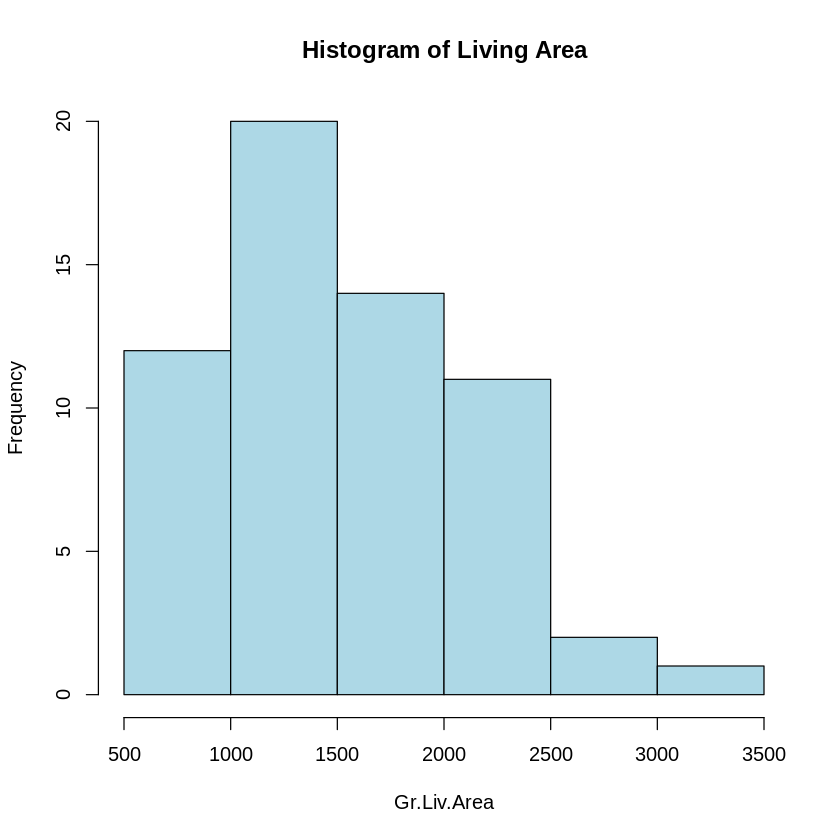

n,Coverage,Avg_Length
<dbl>,<dbl>,<dbl>
30,0.92,359.0694
75,0.96,231.6066
120,0.98,184.2517


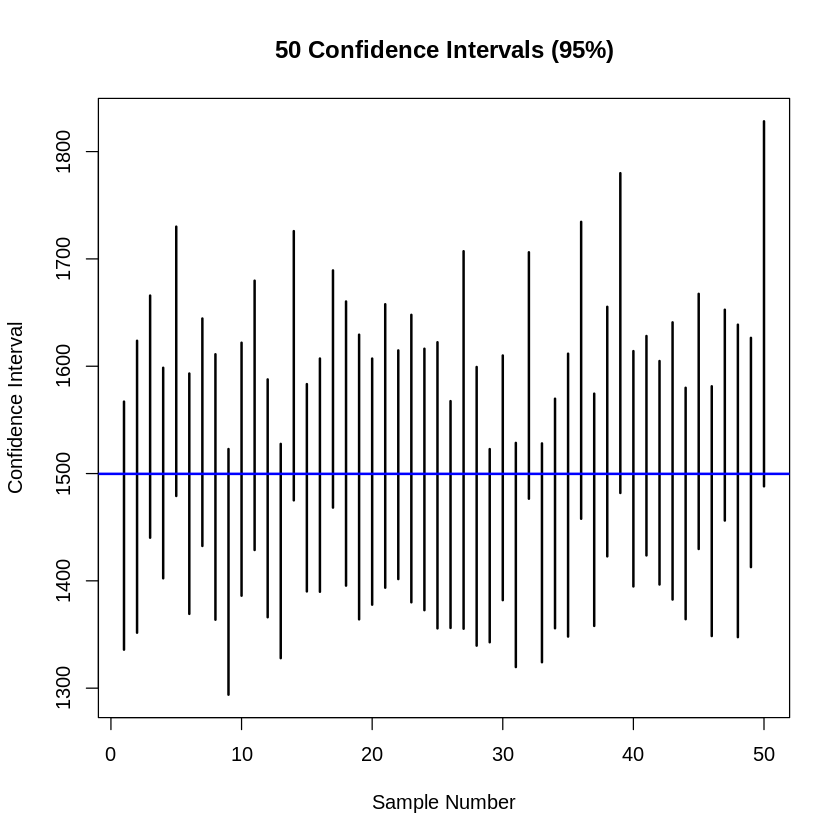

In [27]:

set.seed(810103496)

#Load
ames <- read.csv("http://www.jkarreth.net/files/ames.csv")
data <- ames$Gr.Liv.Area

#Part
n <- 60
sample_data <- sample(data, size = n)

x_bar <- mean(sample_data)
s <- sd(sample_data)

hist(sample_data,
     main = "Histogram of Living Area",
     xlab = "Gr.Liv.Area",
     col = "lightblue")


#Part 2
alpha <- 0.05
t_critical <- qt(1 - alpha/2, df = n - 1)
standard_error <- s / sqrt(n)
margin_error <- t_critical * standard_error

CI_95 <- c(x_bar - margin_error, x_bar + margin_error)
CI_95

#Part 3
CI_90 <- x_bar + c(-1,1) * qt(0.95, df=n-1) * standard_error
CI_99 <- x_bar + c(-1,1) * qt(0.995, df=n-1) * standard_error

list(
  "90%" = CI_90,
  "95%" = CI_95,
  "99%" = CI_99
)

#Part 4
n <- 75
B <- 50

lower <- numeric(B)
upper <- numeric(B)

for (i in 1:B) {
  samp <- sample(data, n)
  x_bar <- mean(samp)
  s <- sd(samp)


  me <- qt(0.975, df=n-1) * s / sqrt(n)
  lower[i] <- x_bar - me
  upper[i] <- x_bar + me
}
#Part 5
mu_true <- mean(data)

coverage <- mean(lower <= mu_true & upper >= mu_true)
coverage

#Part 6
plot(1:B, lower, ylim=c(min(lower), max(upper)),
     type="n",
     xlab="Sample Number",
     ylab="Confidence Interval",
     main="50 Confidence Intervals (95%)")


for (i in 1:B) {
  col <- ifelse(lower[i] <= mu_true & upper[i] >= mu_true, "black", "red")
  segments(i, lower[i], i, upper[i], col=col, lwd=2)
}

abline(h = mu_true, col="blue", lwd=2)
#Part 7
n_values <- c(30, 75, 120)

results <- data.frame(n=n_values, Coverage=NA, Avg_Length=NA)

for (j in 1:length(n_values)) {
  n <- n_values[j]
  lower <- upper <- numeric(B)

  for (i in 1:B) {
    samp <- sample(data, n)
    x_bar <- mean(samp)
    s <- sd(samp)
    me <- qt(0.975, df=n-1) * s / sqrt(n)
    lower[i] <- x_bar - me
    upper[i] <- x_bar + me
  }

  results$Coverage[j] <- mean(lower <= mu_true & upper >= mu_true)
  results$Avg_Length[j] <- mean(upper - lower)
}

results


# Hypothesis Testing

You are a Quantitative Analyst  hired by a venture capital firm. A fintech startup is seeking \$10 million in funding for their new stock trading bot.
They claim their AI can predict whether a stock will go UP or DOWN with accuracy significantly better than a random guess \(p > 0.5).

## Part 1 - The Standard Audit

The Evidence:

To prove it, they deployed the bot on the live market. Here are the results:
* Total Trades: 100
* Successful Predictions: 62
* Sucess Rate: 62%

Your job is to determine if this 62% accuracy is genuine skill or just statistical noise.

First, you must treat their claim at face value using hypothesis testing.

Your Tasks:
1. **Define Hypotheses:** $$H_0: p = 0.5$$ (The AI is guessing randomly).
$$H_A: p > 0.5$$ (The AI has predictive skill).
2. **Check Conditions:** We can only use the Normal Approximation if $np > 10$ and $n(1-p) > 10$. Verify that the conditions are met.
3. **Calculate Z-Score:** Reminder:$$Z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0(1-p_0)}{n}}}$$
4. **Calculate P-Value:** Find the probability of a random guesser getting 62% or higher.

In [28]:
# The startup's data
n_trades <- 100
successes <- 62
p_hat <- successes / n_trades
p_null <- 0.5

In [29]:

cond_success <- n_trades * p_null  # np
cond_failure <- n_trades * (1 - p_null)  # n(1-p)

z_score <- (p_hat - p_null) / sqrt((p_null * (1 - p_null)) / n_trades)

p_value <- 1 - pnorm(z_score)


cond_success <- n_trades * p_null  # np
cond_failure <- n_trades * (1 - p_null)  # n(1-p)

if(cond_success > 10 & cond_failure > 10)
{
  print("Conditions met: We can use the Normal Approximation (CLT).")
} else
{
  print("Warning: Sample size too small.")
}

[1] "Conditions met: We can use the Normal Approximation (CLT)."


In [30]:
# TODO
z_score <- (p_hat - p_null) / sqrt((p_null * (1 - p_null)) / n_trades)



print(paste("Z-Score:", round(z_score, 4)))

[1] "Z-Score: 2.4"


In [31]:
# TODO
# Calculate P-Value
p_value <- 1 - pnorm(z_score)
print(paste("P-Value (Is this luck?):", round(p_value, 4)))

[1] "P-Value (Is this luck?): 0.0082"


## Part 2 - Visualizing the Null Hypothesis

The P-value in Part 1 is a number. To convince the investors, you want to see the distribution of luck. You decide to simulate a "Random Bot" that just flips a coin 100 times, and repeat this 10,000 times to see how often a Random Bot looks like a genius.

Your Tasks:
1. Simulate 10,000 runs of 100 coin flips ($p=0.5$).
2. Plot the histogram of success rates.
3. Draw a line at the startup's performance (0.62).

In [32]:

B <- 10000
n_flips <- 100


random_bots <- replicate(B, mean(sample(c(0, 1), n_flips, replace = TRUE)))




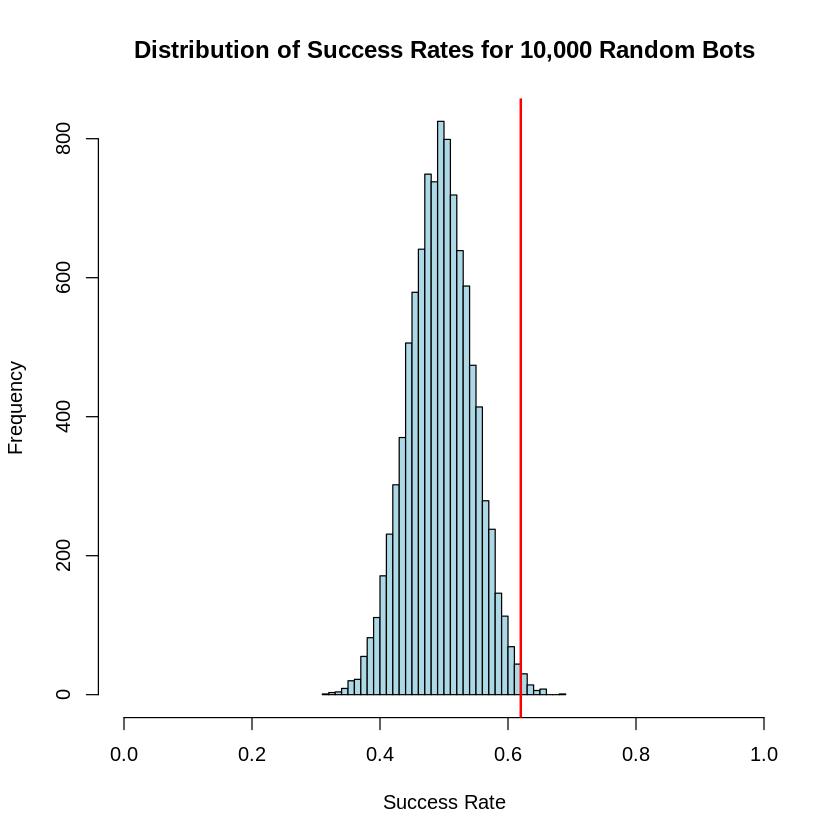

In [33]:

hist(random_bots,
     main="Distribution of Success Rates for 10,000 Random Bots",
     xlab="Success Rate",
     col="lightblue",
     xlim=c(0, 1),
     breaks=30)


abline(v = 0.62, col = "red", lwd = 2)


## Part 3 - The Audit Reveal

During your audit, you inspect their server logs. You discover a folder named Old_Models. It turns out the startup didn't train just one AI. They initialized 200 different random algorithms with slight variations. They had all 200 bots trade on the market. They deleted the 199 that lost money and only presented you with the single best performer. We call that bot, the Survivor.

Your Tasks:
1. **Simulate the Scandal:** Write a loop to simulate their actual process(Create a batch of 200 "Random Bots" ($p=0.5$). Find the maximum win rate in that batch (the "Survivor"). Store that maximum.)
2. Repeat this 1000 times to create a distribution of "Survivors."
3. Re-Evaluate: Does the 62% performance still look impressive when compared to the "Best of 200" distribution?

*In other words, We need to know: If we create 200 random bots, what are the odds that the luckiest one gets 62% or higher?*

In [34]:
n_audits <- 1000       # Number of times we simulate the company's full cycle
n_bots_hidden <- 200   # The number of bots they actually tried
best_of_batch <- numeric(n_audits) # The accuracy of the winner of each round

In [35]:

for (i in 1:n_audits) {

  random_bots <- replicate(n_bots_hidden, mean(sample(c(0, 1), 100, replace = TRUE)))

  best_of_batch[i] <- max(random_bots)
}


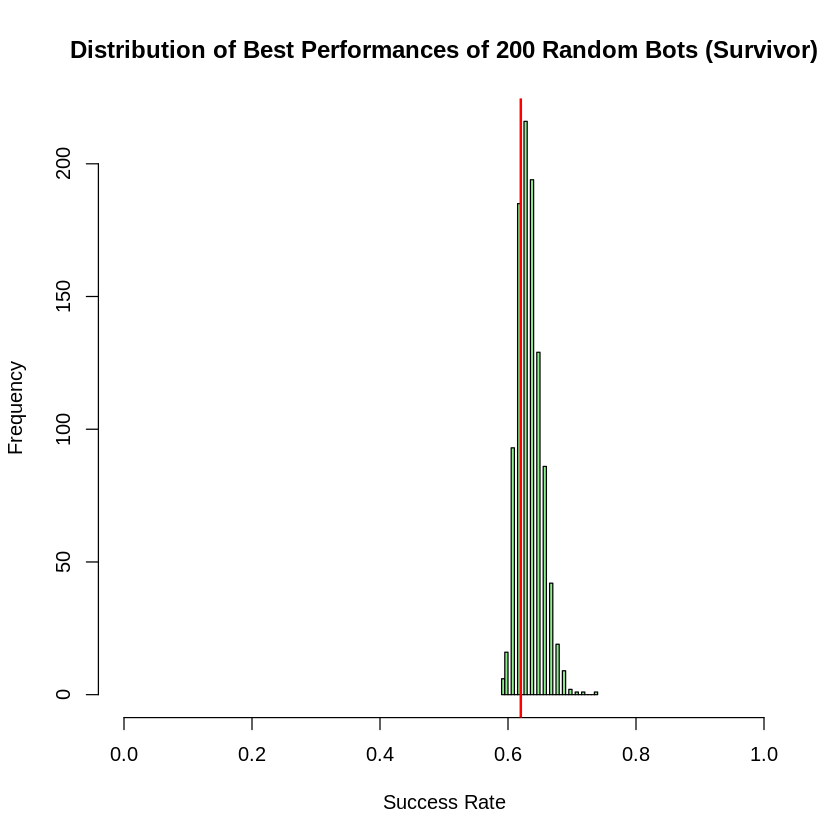

In [36]:
hist(best_of_batch,
     main="Distribution of Best Performances of 200 Random Bots (Survivor)",
     xlab="Success Rate",
     col="lightgreen",
     xlim=c(0, 1),
     breaks=30)

abline(v = 0.62, col = "red", lwd = 2)


In [37]:

p_value_corrected <- mean(best_of_batch >= 0.62)


print(paste("Original Naive P-Value:", round(p_value, 4)))
print(paste("Corrected P-Value (Survivorship Bias):", round(p_value_corrected, 4)))

[1] "Original Naive P-Value: 0.0082"
[1] "Corrected P-Value (Survivorship Bias): 0.885"


In [38]:
# Final Decision
if(p_value_corrected > 0.05)
{
  print("CONCLUSION: DO NOT INVEST. The result is indistinguishable from luck!")
} else
{
  print("CONCLUSION: INVEST. The AI shows skill even after accounting for selection bias.")
}

[1] "CONCLUSION: DO NOT INVEST. The result is indistinguishable from luck!"
